In [1]:
!pwd

/users/khordadi/truejit/evaluation/compilation-plan


In [2]:
import os
import sys
from pathlib import Path
from solver import *
from profiling import *
import numpy as np

In [3]:
benchmark = ffmpeg

In [4]:
# compile statically the binary
# static_compile(benchmark.binary)

In [5]:
static_info = get_static_info(benchmark.binary)

In [ ]:
recorder = Recorder()

In [6]:
out_dir = Path('out') / 'key-results'
out_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# training sets
# out/key-results/datasets/<benchmark>/<workload>/<dataset>.csv
datasets_path = out_dir / 'datasets' / benchmark.name
datasets_path.mkdir(parents=True, exist_ok=True)

for wl in benchmark.workloads:
    print(f'[workload] {wl.name}')
    workload_dataset_path = datasets_path / wl.name
    workload_dataset_path.mkdir(parents=True, exist_ok=True)

    # oracle 
    profile_path = profiles_root(benchmark.binary, wl.name) / 'profile.csv'
    profile = pd.read_csv(profile_path)
    profile.to_csv(workload_dataset_path / 'oracle.csv', index=False, columns=[
        'id',
        'name',
        'size.bytecode',
        'size.static',

        'start.jit',
        'exec.jit',
        'freq.jit',
        'compilation.jit',
        'size.dynamic.jit',

        'start.interp',
        'exec.interp',
        'freq.interp',

        'exec.spec',
        'compilation.spec',
        'size.dynamic.spec'
    ])

    # leave-one-out
    profiles = []
    for training_on_wl in benchmark.workloads:
        if wl.name == training_on_wl.name:
            continue

        profile_path = profiles_root(benchmark.binary, training_on_wl.name) / 'profile.csv'
        profiles.append(pd.read_csv(profile_path))

    concat_profile = concat_profiles(profiles)
    concat_profile.to_csv(workload_dataset_path / 'leave_one_out.csv', index=False, columns=[
        'id',
        'name',
        'size.bytecode',
        'size.static',

        'start.jit',
        'exec.jit',
        'freq.jit',
        'compilation.jit',
        'size.dynamic.jit',

        'start.interp',
        'exec.interp',
        'freq.interp',

        'exec.spec',
        'compilation.spec',
        'size.dynamic.spec'
    ])

In [7]:
code_sizes  = []
for wl in benchmark.workloads:
    base_profile = pd.read_csv(profiles_root(benchmark.binary, wl.name) / "profile.csv")
    code_sizes.append(sum(base_profile['size.dynamic.jit']))
[f'{code_size / 1.e6:.2f}' for code_size in code_sizes]

['5.07',
 '4.97',
 '2.98',
 '5.31',
 '3.03',
 '2.80',
 '5.08',
 '2.92',
 '2.79',
 '3.35',
 '5.09',
 '5.09',
 '5.07',
 '4.69',
 '3.13',
 '5.11']

In [8]:
plan_name = 'min_e2e.dynamic_code_half.static_code_quarter.default_jit'

In [9]:
# planning
# out/key-results/plans/<benchmark>/<workload>/<plan>.<dataset>.json
plans_dir = out_dir / 'plans' / benchmark.name
plans_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
goal = EndToEndTime()
default = 'jit'


for i, wl in enumerate(benchmark.workloads):
    workload_plans_dir = plans_dir / wl.name
    workload_plans_dir.mkdir(parents=True, exist_ok=True)

    max_dynamic_code_size = int(code_sizes[i] // 2)
    max_static_code_size = int(code_sizes[i] // 4)
    constraints = [
        Constraint(DynamicCodeSize(), upper_bound=max_dynamic_code_size),
        Constraint(StaticCodeSize(), upper_bound=max_static_code_size)
    ]
        
    dataset_path = datasets_path / wl.name / 'oracle.csv'
    dataset = pd.read_csv(dataset_path)
    planner = Planner(goal, constraints, default)
    plan = planner.plan(static_info, dataset)
    planner.to_json(workload_plans_dir / f'{plan_name}.oracle.json')

    dataset_path = datasets_path / wl.name / 'leave_one_out.csv'
    dataset = pd.read_csv(dataset_path)
    planner = Planner(goal, constraints, default)
    plan = planner.plan(static_info, dataset)
    planner.to_json(workload_plans_dir / f'{plan_name}.leave_one_out.json')

In [10]:
# execution
profiles_path = out_dir / 'profiles' / benchmark.name
profiles_path.mkdir(parents=True, exist_ok=True)

In [ ]:
for wl in benchmark.workloads:
    workload_profiles_path = profiles_path / wl.name
    workload_profiles_path.mkdir(parents=True, exist_ok=True)

    print(f'[workload] {wl.name}')
    for plan in [
        f'{plan_name}.oracle',
        f'{plan_name}.leave_one_out',
    ]:
        print(f'[plan] {plan}')
        plan_path = plans_dir / wl.name / f'{plan}.json'
        !ls {plan_path.absolute()}
        for _ in range(3):
            recorder.record(benchmark.binary,
                            wl,
                            options=['--interp=planned', 
                                     '--async=planned', 
                                     '--static=planned',
                                     '--specialize=planned'],
                            profile_path=(workload_profiles_path / plan).absolute(),
                            env={'PLAN': plan_path.absolute()})

In [12]:
datas = []
rows = []

for dataset, plan in [
        ('oracle', f'{plan_name}.oracle'),
        ('leave_one_out', f'{plan_name}.leave_one_out'),
    ]:
    for wl in benchmark.workloads:
        profile_path = profiles_path / wl.name / plan
        profile = Profile(profile_path)
        if not profile.e2e:
            raise RuntimeError(f'No profile runs found at {profile_path}')

        metrics = {
            'e2e': profile.e2e,
            'waiting': profile.waiting,
            'dynamic.code.size': profile.dynamic_code_size,
            'static.code.size': profile.static_code_size,
            'cpu': [exec_time + compilation_time for exec_time, compilation_time in zip(profile.exec, profile.compilation)],
        }

        datas.append({
            'dataset': dataset,
            'workload': wl.name,
            **metrics,
        })

        runs = max(len(values) for values in metrics.values())
        for run in range(runs):
            row = {
                'dataset': dataset,
                'workload': wl.name,
                'run': run,
            }
            for metric, values in metrics.items():
                row[metric] = values[run] if run < len(values) else np.nan
            rows.append(row)

data_df = pd.DataFrame(rows)
data_df


,dataset,workload,run,e2e,waiting,dynamic.code.size,static.code.size,cpu
0,oracle,mov-to-mp4,0,101771987956,47910251,1498952,1266848,102747973787
1,oracle,mov-to-mp4,1,101715285545,47423499,1498952,1266848,102688676947
2,oracle,mov-to-mp4,2,101743952454,47689197,1498952,1266848,102716358841
3,oracle,mov-to-mp4,3,101791373443,47812830,1498952,1266848,102763506298
4,oracle,mp4-to-mkv,0,97979615486,57124763,1456360,1243504,98884060732
...,...,...,...,...,...,...,...,...
123,leave_one_out,mp4-to-flac,3,2413869128,1669646387,1082904,782048,4816140501
124,leave_one_out,mp4-gaussian-blur,0,131053115905,198425732,1573504,1278696,132454304851
125,leave_one_out,mp4-gaussian-blur,1,136906916014,196777212,1573504,1278696,138305382839
126,leave_one_out,mp4-gaussian-blur,2,130704856886,201917837,1573504,1278696,132106389540


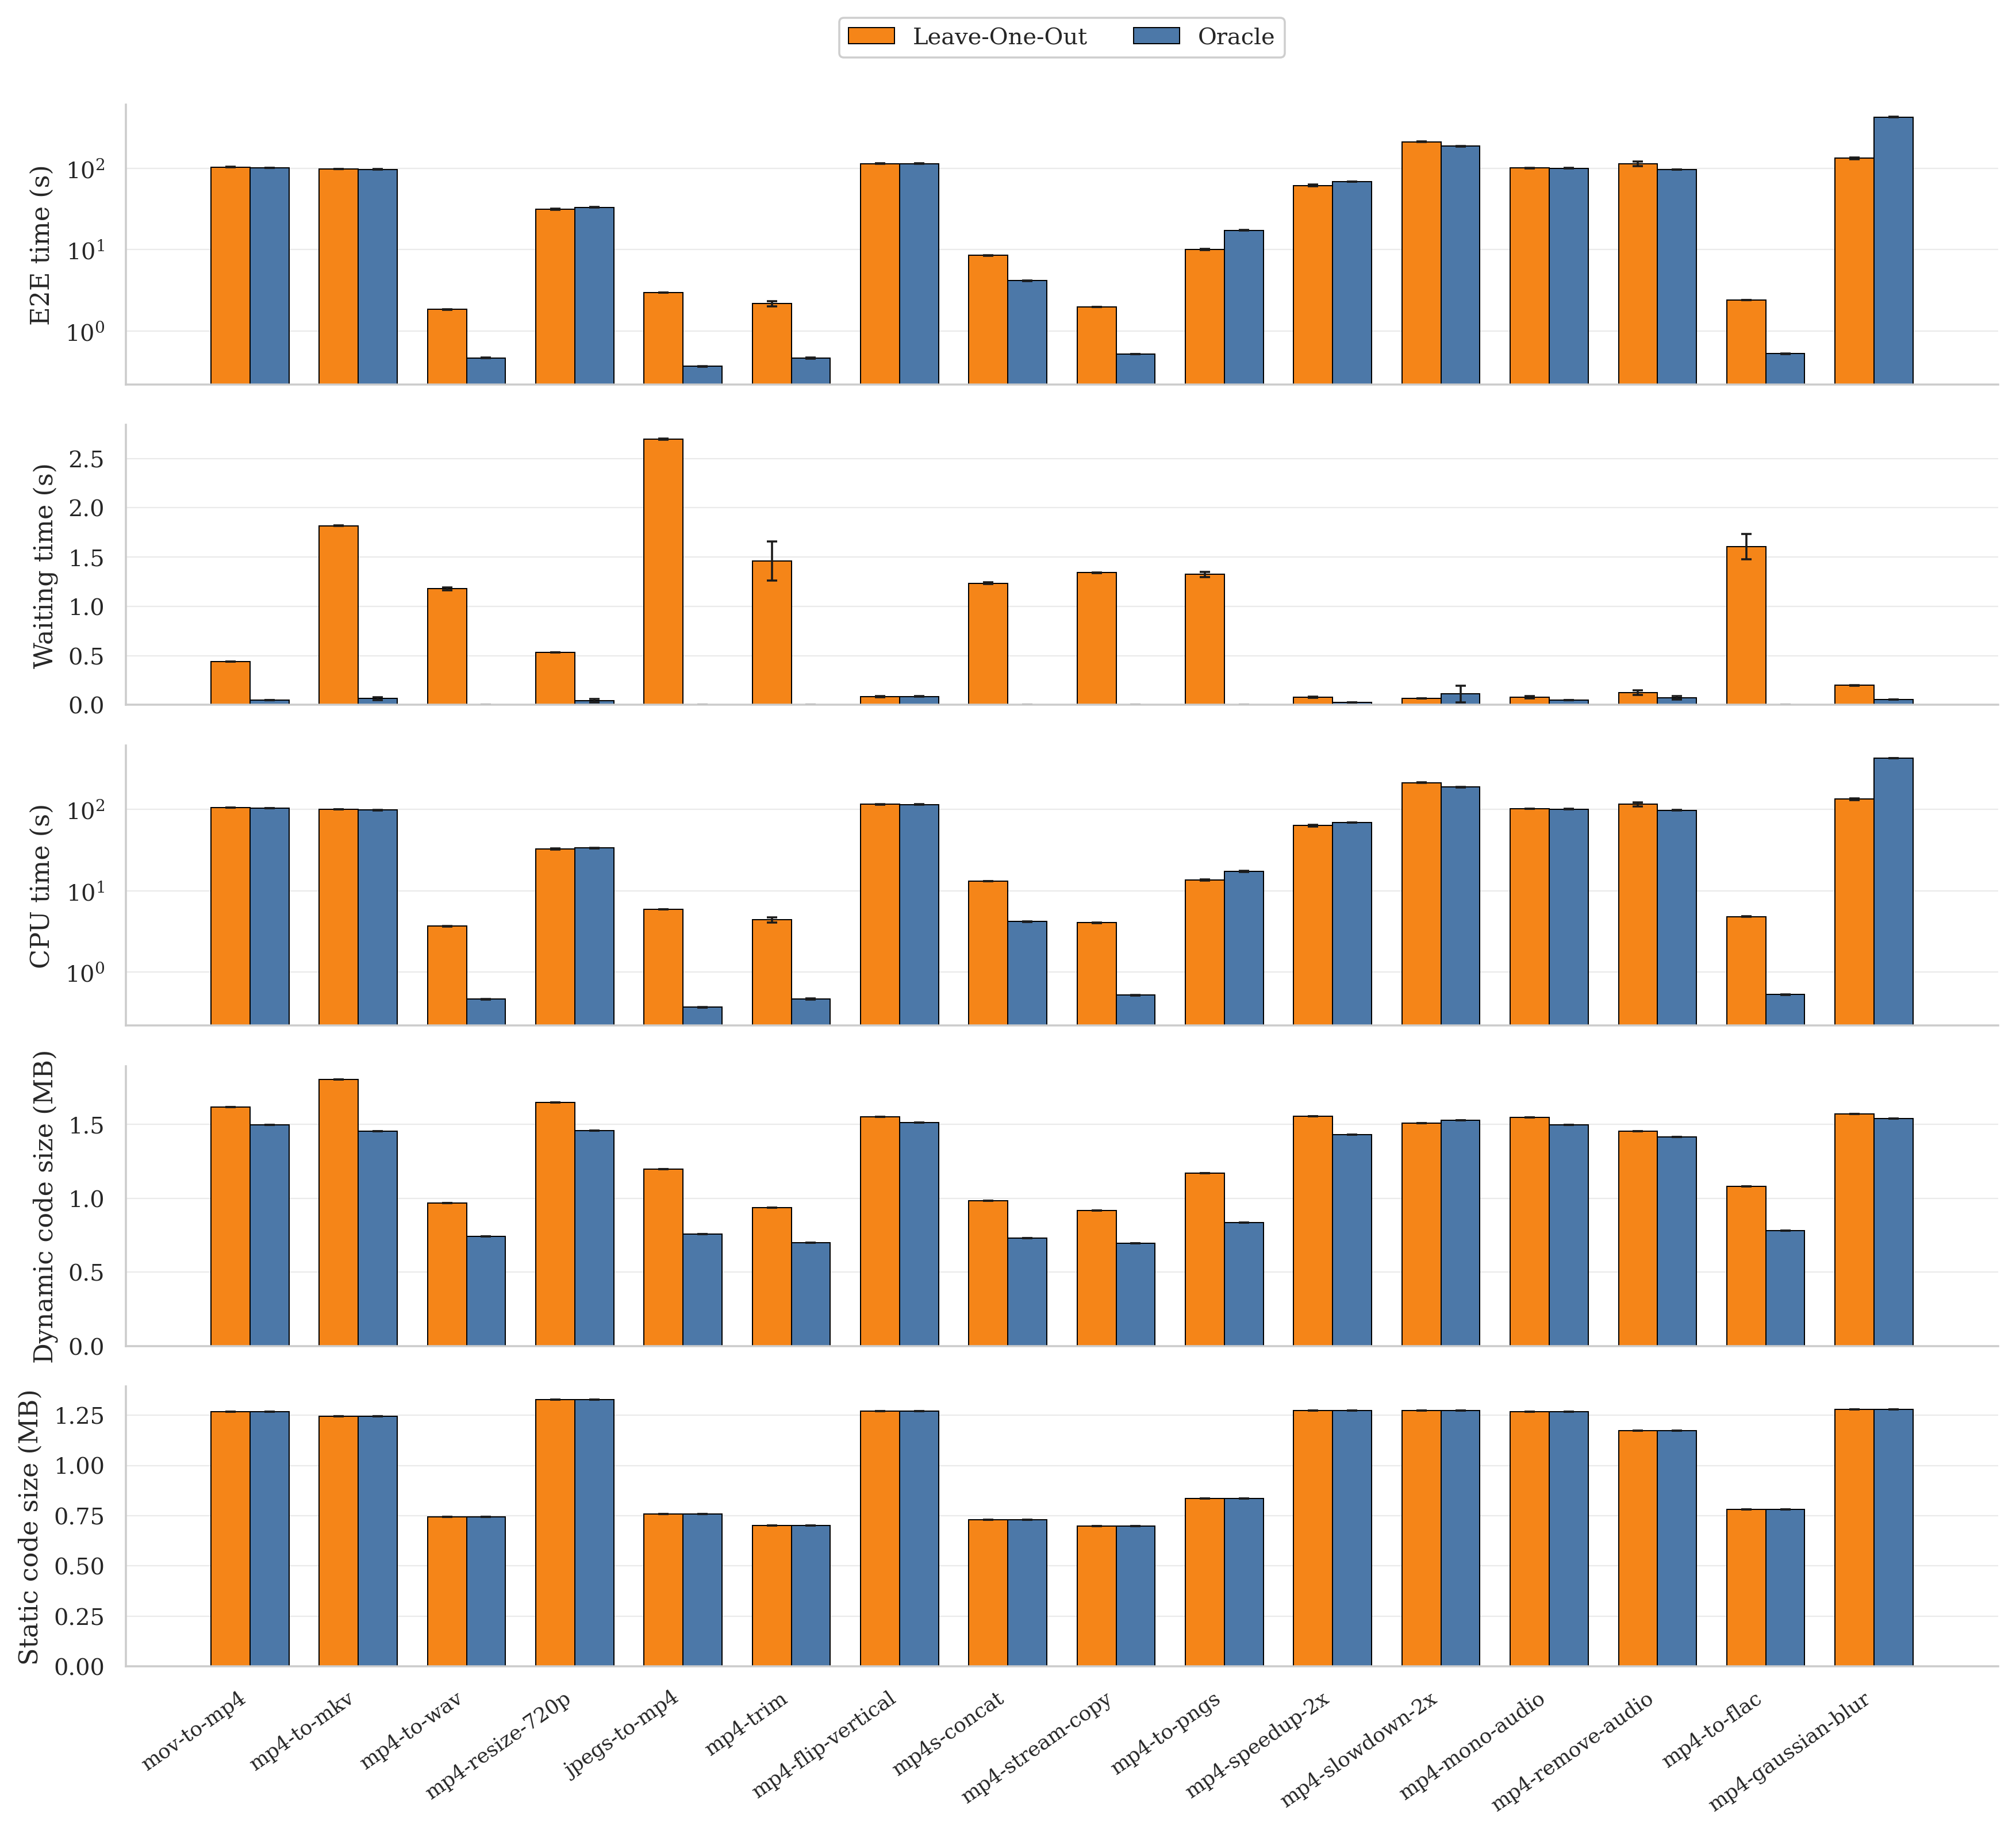

(PosixPath('out/key-results/loo-vs-oracle.pdf'),
 PosixPath('out/key-results/loo-vs-oracle.raw.csv'),
 PosixPath('out/key-results/loo-vs-oracle.summary.csv'))

In [14]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', context='paper', font='serif')
mpl.rcParams.update({
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 9,
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'grid.alpha': 0.4,
})

metrics = [
    ('e2e', 'E2E time (s)', 1e9, 'log'),
    ('waiting', 'Waiting time (s)', 1e9, 'linear'),
    ('cpu', 'CPU time (s)', 1e9, 'log'),
    ('dynamic.code.size', 'Dynamic code size (MB)', 1e6, 'linear'),
    ('static.code.size', 'Static code size (MB)', 1e6, 'linear'),
]

dataset_order = ['leave_one_out', 'oracle']
dataset_labels = {
    'oracle': 'Oracle',
    'leave_one_out': 'Leave-One-Out',
}
workload_order = [wl.name for wl in benchmark.workloads]

summary_df = (
    data_df
    .groupby(['workload', 'dataset'])
    .agg({metric: ['mean', 'std', 'count'] for metric, *_ in metrics})
    .reset_index()
)
summary_df.columns = [
    '.'.join(col).strip('.') if isinstance(col, tuple) else col
    for col in summary_df.columns
]

raw_path = out_dir / 'loo-vs-oracle.raw.csv'
summary_path = out_dir / 'loo-vs-oracle.summary.csv'
pdf_path = out_dir / 'loo-vs-oracle.pdf'

data_df.to_csv(raw_path, index=False)
summary_df.to_csv(summary_path, index=False)

fig, axes = plt.subplots(
    len(metrics), 1,
    figsize=(11, 10),
    dpi=320,
    sharex=True,
)

xs = np.arange(len(workload_order))
bar_width = 0.36
palette = {
    'oracle': '#4C78A8',
    'leave_one_out': '#F58518',
}

for ax, (metric, ylabel, divisor, yscale) in zip(axes, metrics):
    metric_values = data_df[metric] / divisor

    for dataset_idx, dataset in enumerate(dataset_order):
        means = []
        stds = []
        for workload in workload_order:
            values = (
                data_df[
                    (data_df['workload'] == workload) &
                    (data_df['dataset'] == dataset)
                ][metric]
                .dropna()
                .to_numpy(dtype=float) / divisor
            )
            means.append(float(np.mean(values)) if len(values) else np.nan)
            stds.append(float(np.std(values, ddof=1)) if len(values) > 1 else 0.0)

        offset = (dataset_idx - (len(dataset_order) - 1) / 2) * bar_width
        ax.bar(
            xs + offset,
            means,
            width=bar_width,
            yerr=stds,
            error_kw={'elinewidth': 0.8, 'capsize': 2, 'capthick': 0.8},
            color=palette[dataset],
            edgecolor='black',
            linewidth=0.45,
            label=dataset_labels[dataset],
        )

    if yscale == 'log':
        positives = metric_values[metric_values > 0]
        if len(positives):
            ax.set_yscale('log')
            ax.set_ylim(bottom=max(float(positives.min()) * 0.6, 1e-4))

    ax.set_ylabel(ylabel)
    ax.yaxis.grid(True)
    ax.grid(False, axis='x')
    ax.set_axisbelow(True)

axes[0].legend(
    title=None,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.35),
    ncol=2,
    frameon=True,
    framealpha=0.95,
    edgecolor='0.8',
)
axes[-1].set_xticks(xs)
axes[-1].set_xticklabels(workload_order, rotation=35, ha='right')

sns.despine(fig=fig)
fig.tight_layout()
fig.savefig(pdf_path, dpi=320, bbox_inches='tight', pad_inches=0.02, transparent=True)
plt.show()

pdf_path, raw_path, summary_path